In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vinay04kasana/video2/4208194-uhd_3840_2160_24fps.mp4
/kaggle/input/datasets/vinay04kasana/car-parking-folder/car-videos/12600828_3840_2160_30fps.mp4
/kaggle/input/datasets/vinay04kasana/car-parking-folder/car-videos/13047727_2160_3840_30fps.mp4
/kaggle/input/datasets/vinay04kasana/car-parking-folder/car-videos/9701948-uhd_3840_2160_30fps.mp4
/kaggle/input/datasets/vinay04kasana/car-parking-folder/car-videos/5587732-uhd_3700_2082_30fps.mp4
/kaggle/input/datasets/vinay04kasana/car-parking-folder/car-videos/5233757-uhd_3840_2160_30fps.mp4
/kaggle/input/datasets/vinay04kasana/car-video/13119394_3840_2160_25fps.mp4
/kaggle/input/datasets/vinay04kasana/parking/README.dataset.txt
/kaggle/input/datasets/vinay04kasana/parking/README.roboflow.txt
/kaggle/input/datasets/vinay04kasana/parking/data.yaml
/kaggle/input/datasets/vinay04kasana/parking/valid/labels/GOPR6691_JPG_jpg.rf.f3a95864301f1dbce2fb6c9b12c3dd24.txt
/kaggle/input/datasets/vinay04kasana/parking/valid/labels/Wh

In [2]:
import subprocess
import sys

# Install ultralytics (YOLOv8)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch"])

print("✓ Dependencies installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:00
✓ Dependencies installed successfully!


In [3]:
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("✓ Libraries imported successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Libraries imported successfully!


In [4]:
# Dataset path
dataset_path = Path("/kaggle/input/datasets/vinay04kasana/parking")
data_yaml = dataset_path / "data.yaml"

# Verify dataset exists
if dataset_path.exists():
    print(f"✓ Dataset found at: {dataset_path.absolute()}")
    
    # List dataset structure
    print("\nDataset Structure:")
    for split in ['train', 'valid', 'test']:
        split_path = dataset_path / split
        if split_path.exists():
            images = list((split_path / 'images').glob('*'))
            labels = list((split_path / 'labels').glob('*'))
            print(f"  {split}: {len(images)} images, {len(labels)} labels")
else:
    print(f"✗ Dataset not found at: {dataset_path}")

# Check if data.yaml exists
if data_yaml.exists():
    print(f"\n✓ data.yaml found")
    with open(data_yaml, 'r') as f:
        print("data.yaml content:")
        print(f.read())
else:
    print(f"✗ data.yaml not found at: {data_yaml}")

✓ Dataset found at: /kaggle/input/datasets/vinay04kasana/parking

Dataset Structure:
  train: 3321 images, 3321 labels
  valid: 318 images, 318 labels
  test: 157 images, 157 labels

✓ data.yaml found
data.yaml content:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['Car', 'Space Available', 'busy', 'free']

roboflow:
  workspace: vinay-kasana
  project: autonomous-parking-system
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/vinay-kasana/autonomous-parking-system/dataset/2


In [5]:
print("Loading pretrained YOLOv8 model...")
model = YOLO("yolov8m.pt")  # medium model - balanced between speed and accuracy
print("✓ Model loaded successfully!")

# Train the model
print("\nStarting training...")
print("This may take several minutes depending on your hardware...\n")

results = model.train(
    data=str(data_yaml),           # path to data.yaml
    epochs=60,                      # number of epochs
    imgsz=798,                      # image size
    batch=16,                        # batch size (adjust based on GPU memory)
    patience=30,                    # early stopping patience
    device=0,                       # GPU device (0 for first GPU, CPU if no GPU)
    project="parking_detection",    # project directory
    name="yolov8m_parking",         # experiment name
    exist_ok=False,                 # don't overwrite existing experiment
    save=True,                      # save training checkpoints
    save_period=10,                 # save every N epochs
    verbose=True,                   # verbose output
    pretrained=True,                # use pretrained weights
    optimizer="AdamW",                # optimizer
    seed=42                         # for reproducibility
)

print("\n✓ Training completed!")
print(f"Results saved to: parking_detection/yolov8m_parking")

Loading pretrained YOLOv8 model...
✓ Model loaded successfully!

Starting training...
This may take several minutes depending on your hardware...

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/vinay04kasana/parking/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=798, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mo

In [6]:
# Load the best trained model
best_model_path = Path("runs/detect/parking_detection/yolov8m_parking/weights/best.pt")
if best_model_path.exists():
    print(f"Loading best model from: {best_model_path}")
    best_model = YOLO(str(best_model_path))
    
    # Validate on the validation set
    print("\nValidating on validation set...")
    val_results = best_model.val()
    
    print("\n" + "="*50)
    print("VALIDATION METRICS")
    print("="*50)
    print(f"mAP50: {val_results.box.map50:.4f}")
    print(f"mAP50-95: {val_results.box.map:.4f}")
    print(f"Precision: {val_results.box.mp:.4f}")
    print(f"Recall: {val_results.box.mr:.4f}")
else:
    print(f"Best model not found at: {best_model_path}")
    print("Make sure training completed successfully.")

Loading best model from: runs/detect/parking_detection/yolov8m_parking/weights/best.pt

Validating on validation set...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 57.8±24.1 MB/s, size: 36.1 KB)
val: Scanning /kaggle/input/datasets/vinay04kasana/parking/valid/labels... 318 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 318/318 695.2it/s 0.5s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/vinay04kasana/parking/valid is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 4006, len(boxes) = 8975. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50 

Running inference on 50 randomly selected validation images...

Processing: VID_20230926153919_mp4-108_jpg.rf.197000404a8f1feeaefeb0530846229c.jpg
Processing: gv09nsefx5vb1_1s2vifu_jpeg_jpg.rf.593fbc1589dbc27bd3395b254fc049c3.jpg
Processing: GOPR6596_JPG_jpg.rf.9a1c0401297f9a5b7527ad6c312b4efd.jpg
Processing: WhatsApp-Video-2023-09-14-at-14_20_14_mp4-14_jpg.rf.e2740b6bcafae39e5982828d06bdca0d.jpg
Processing: 1647291346_14-kartinkin-net-p-parkovka-kartinki-15_jpg.rf.1bf401b6420d49f4db18f86e172ad2c7.jpg
Processing: WhatsApp-Video-2023-09-14-at-14_20_14_mp4-336_jpg.rf.33864eeee26fcb31012a340066eaa68e.jpg
Processing: WhatsApp-Video-2023-09-14-at-14_32_36_mp4-41_jpg.rf.9d035e82eab8d1efa17b1045496cb509.jpg
Processing: 1647291447_44-kartinkin-net-p-parkovka-kartinki-47_jpg.rf.90b66f5d40b12c29ab6b989fdc7be845.jpg
Processing: 1647291412_35-kartinkin-net-p-parkovka-kartinki-37_jpg.rf.b7d68ec22c81d308f4267ac21f041c73.jpg
Processing: VID_20230926153919_mp4-19_jpg.rf.cf1fb6eb2b2f2bf7ad1911df351a8b8

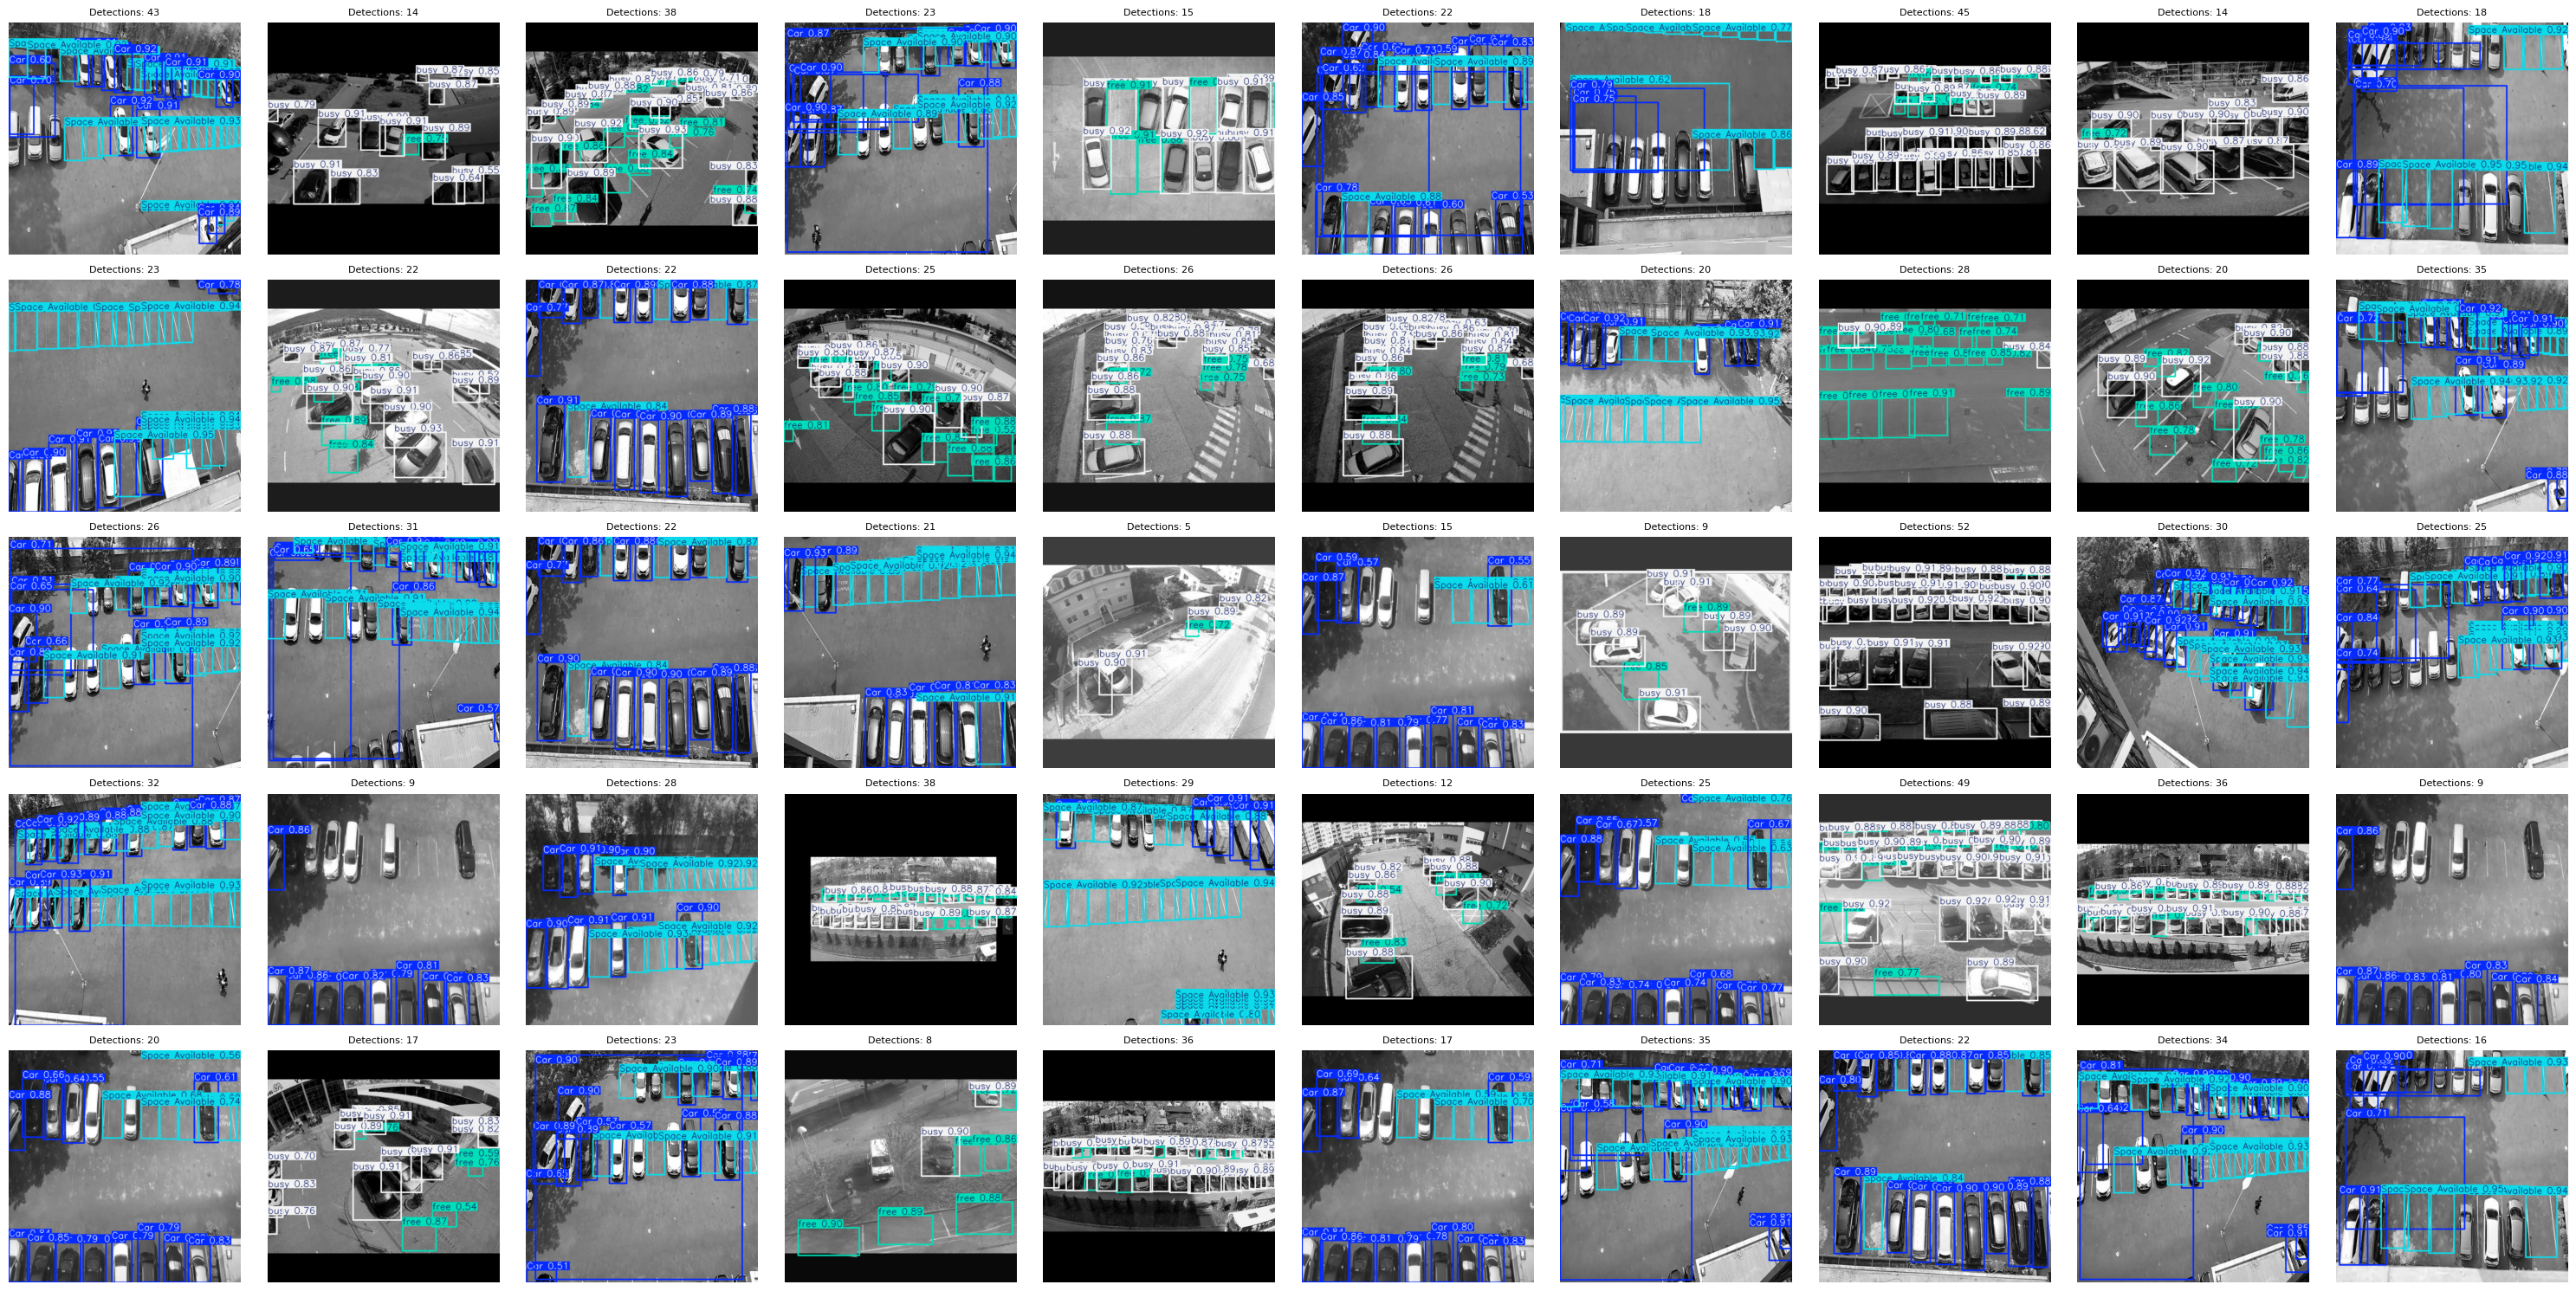


✓ Sample predictions saved to: sample_predictions_50.png


In [7]:
from pathlib import Path
import random

# Get validation images
valid_images_path = Path("/kaggle/input/datasets/vinay04kasana/parking/valid/images")

if valid_images_path.exists():
    image_files = list(valid_images_path.glob("*.jpg")) + list(valid_images_path.glob("*.png"))
    
    if image_files:
        # Randomly sample up to 50 images
        num_samples = min(50, len(image_files))
        sampled_images = random.sample(image_files, num_samples)
        
        print(f"Running inference on {num_samples} randomly selected validation images...\n")
        
        # Adjust grid size as you like; here 5x10
        rows, cols = 5, 10
        fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
        axes = axes.flatten()
        
        for idx, img_path in enumerate(sampled_images):
            if idx >= rows * cols:
                break
            
            print(f"Processing: {img_path.name}")
            
            results = best_model.predict(source=str(img_path), conf=0.5, verbose=False)
            result = results[0]
            annotated_img = result.plot()
            
            axes[idx].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(f"Detections: {len(result.boxes)}", fontsize=8)
            axes[idx].axis("off")
        
        # Turn off any unused axes
        for j in range(idx + 1, rows * cols):
            axes[j].axis("off")
        
        plt.tight_layout()
        plt.savefig("sample_predictions_50.png", dpi=100, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Sample predictions saved to: sample_predictions_50.png")
    else:
        print("No validation images found!")
else:
    print(f"Validation images directory not found: {valid_images_path}")
    

In [8]:
!pip install ultralytics opencv-python

import cv2
from ultralytics import YOLO


In [9]:
model = YOLO("/kaggle/working/runs/detect/parking_detection/yolov8m_parking/weights/best.pt")  # or yolov8n.pt etc.


In [10]:
import os
import cv2
from ultralytics import YOLO

# Load your trained model
model = YOLO("/kaggle/working/runs/detect/parking_detection/yolov8m_parking/weights/best.pt")  # or best.pt

# Folder containing videos (INPUT - read only)
video_folder = "/kaggle/input/datasets/vinay04kasana/car-parking-folder/car-videos"

# Folder to save outputs (WRITABLE)
output_folder = "/kaggle/working/processed_videos"
os.makedirs(output_folder, exist_ok=True)

# Loop through all files in folder
for video_file in os.listdir(video_folder):

    if video_file.endswith((".mp4", ".avi", ".mov", ".mkv")):

        video_path = os.path.join(video_folder, video_file)
        print(f"Processing: {video_file}")

        cap = cv2.VideoCapture(video_path)

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)

        output_path = os.path.join(output_folder, f"output_{video_file}")

        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            results = model(frame)
            annotated = results[0].plot()

            out.write(annotated)

        cap.release()
        out.release()

        print(f"Saved: {output_path}")

cv2.destroyAllWindows()

print("✅ All videos processed successfully!")

Processing: 12600828_3840_2160_30fps.mp4

0: 480x800 269 busys, 31 frees, 53.2ms
Speed: 3.3ms preprocess, 53.2ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 800)

0: 480x800 272 busys, 28 frees, 13.9ms
Speed: 3.8ms preprocess, 13.9ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 800)

0: 480x800 271 busys, 29 frees, 13.8ms
Speed: 5.0ms preprocess, 13.8ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 800)

0: 480x800 271 busys, 29 frees, 14.0ms
Speed: 3.4ms preprocess, 14.0ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 800)

0: 480x800 273 busys, 27 frees, 14.1ms
Speed: 4.0ms preprocess, 14.1ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 800)

0: 480x800 270 busys, 30 frees, 13.9ms
Speed: 3.5ms preprocess, 13.9ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 800)

0: 480x800 268 busys, 32 frees, 13.9ms
Speed: 3.9ms preprocess, 13.9ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 800)


CNN